# Machine learning introduction

## 1. Введение: 

__1) Пять примеров применения методов машинного обучения в жизни:__
1. Подбор музыки по прослушенному ранее

2. В продуктовом по фото определять, какой продукт на весах

3. Предсказание загруженности дорог на картах

4. Предсказывания заболеваний по снимкам

5. Проверка документов на корректность по ГОСТу(процент корректности)

__2) По моим примерам:__

1 - классификация (это ранжирование больше, но можно и к классификации добавить)

2 - классификация

3 - регрессия 

4 - классификация 

5 - классификация 

__По примерам из задания получились такие результаты:__

1 - регрессия

2 - классификация

3 - регрессия

4 - классификация

5 - классификация

6 - классификация

7 - регрессия

8 - классификация

9 - кластеризация

10 - классификация

__3) Multiclass выбирает один класс(то есть ответ один), а Multilabel для каждого класса решает отдельно(то есть ответ может быть не один)__

__4) нет, это регрессия.__

Задачу регрессии можно легко свести к классификации, например меняем цену машины, которая задана числом(600к, 3кк), на категории: дешево, средне, дорого.

## 2. Введение в анализ данных

In [464]:
import pandas as pd, numpy as np, lightgbm, scipy, statsmodels, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [465]:
df_start = pd.read_json('../data/train.json')

In [466]:
df_start.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


- Видно, что у нас 15 столбцов и 49352 строк.

In [467]:
df_start.head(0)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level


- Целевой переменной у нас является столбец 'price'.

- По .info() видно, что пустых значений нет.

In [468]:
df_start.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


.corr() не применим к категориальным признакам, поэтому укажем точно, что на нужно

In [469]:
df_start[['bathrooms', 'bedrooms', 'latitude', 'longitude', 'price']].corr()

,bathrooms,bedrooms,latitude,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,-0.966807,-0.000707
longitude,0.010393,0.006892,-0.966807,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,-0.000087,1.000000


In [470]:
df = df_start[['bathrooms', 'bedrooms', 'price', 'interest_level']]
df.head()

,bathrooms,bedrooms,price,interest_level
4,1.0,1,2400,medium
6,1.0,2,3800,low
9,1.0,2,3495,medium
10,1.5,3,3000,medium
15,1.0,0,2795,low


## 3. Анализ статистических данных

Построим гистограмму

Text(0.5, 1.0, 'Histogram')

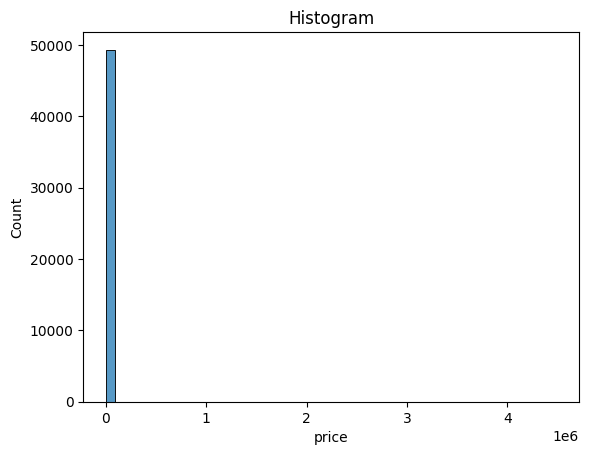

In [471]:
sns.histplot(data=df, x='price', bins=50)
plt.title("Histogram")

- По шкале видно, что цена измеряется по огромной шкале, значит есть выбросы

Text(0.5, 1.0, 'Boxplot')

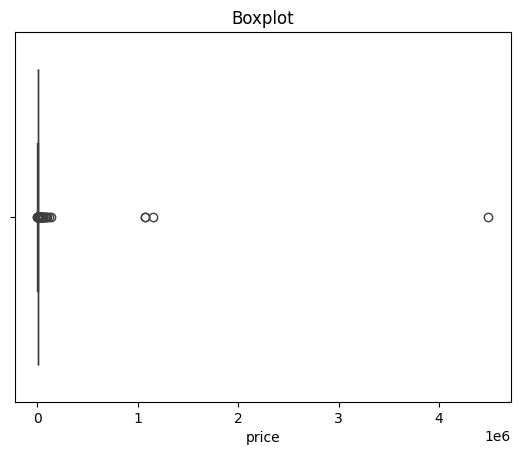

In [472]:
sns.boxplot(data=df, x='price')
plt.title("Boxplot")

- Видно, что есть огромные выбросы которые требуется убрать

In [473]:
lower_q = df['price'].quantile(0.01)
upper_q = df['price'].quantile(0.99)
df_q = df[(df['price'] >= lower_q) & (df['price'] <= upper_q)]

In [474]:
df_q.head()

,bathrooms,bedrooms,price,interest_level
4,1.0,1,2400,medium
6,1.0,2,3800,low
9,1.0,2,3495,medium
10,1.5,3,3000,medium
15,1.0,0,2795,low


Text(0.5, 1.0, 'Histogram')

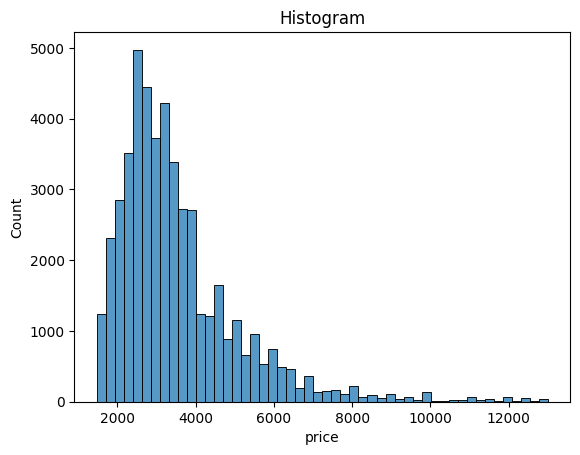

In [475]:
sns.histplot(data=df_q, x='price', bins=50)
plt.title("Histogram")

In [476]:
df_q.head()

,bathrooms,bedrooms,price,interest_level
4,1.0,1,2400,medium
6,1.0,2,3800,low
9,1.0,2,3495,medium
10,1.5,3,3000,medium
15,1.0,0,2795,low


- interest_level - категориальный признак

In [477]:
df_q['interest_level'].unique()

array(['medium', 'low', 'high'], dtype=object)

In [478]:
df_q['interest_level'].count()

48379

In [479]:
df_q['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

- почему бы не заменить категориальный признаки благодаря LabelEncoder

In [480]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

encoder.fit(df['interest_level'])

df_q['interest_level'] = encoder.transform(df_q['interest_level'])

C:\Users\User\AppData\Local\Temp\ipykernel_3724\747471692.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_q['interest_level'] = encoder.transform(df_q['interest_level'])


In [481]:
df_q.head()

,bathrooms,bedrooms,price,interest_level
4,1.0,1,2400,2
6,1.0,2,3800,1
9,1.0,2,3495,2
10,1.5,3,3000,2
15,1.0,0,2795,1


Text(0.5, 1.0, 'Histogram')

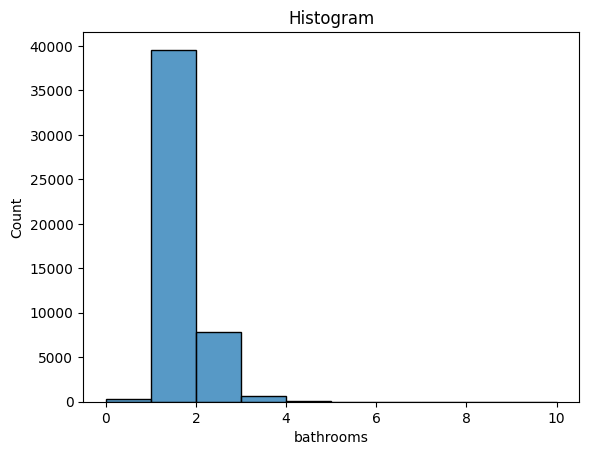

In [482]:
sns.histplot(data=df_q, x='bathrooms', bins=10)
plt.title("Histogram")

Text(0.5, 1.0, 'Histogram')

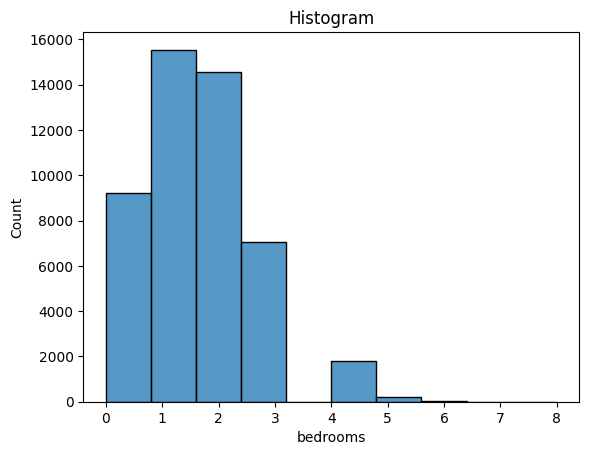

In [483]:
sns.histplot(data=df_q, x='bedrooms', bins=10)
plt.title("Histogram")

- Для ванных и спален мы не видим выбросов

In [484]:
corr_matrix = df_q[['bathrooms', 'bedrooms', 'interest_level', 'price']].corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.006578,0.671943
bedrooms,0.517574,1.000000,0.028754,0.545948
interest_level,-0.006578,0.028754,1.000000,-0.033239
price,0.671943,0.545948,-0.033239,1.000000


<Axes: >

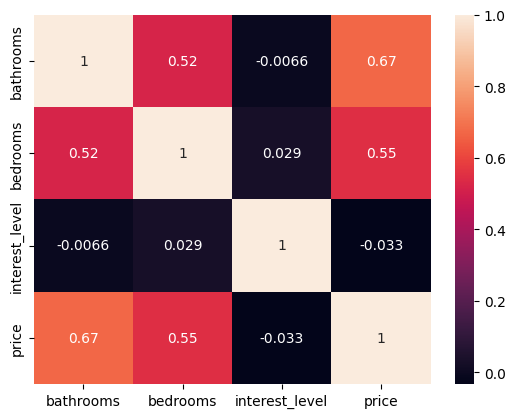

In [485]:
sns.heatmap(corr_matrix, annot=True)

- Да, корреляция есть. C количеством комнат она наибольшая (0,67). Также довольно высокая с количеством ванных комнат (0.55). А вот с уровнем интереса совсем нет корреляционной зависимости.

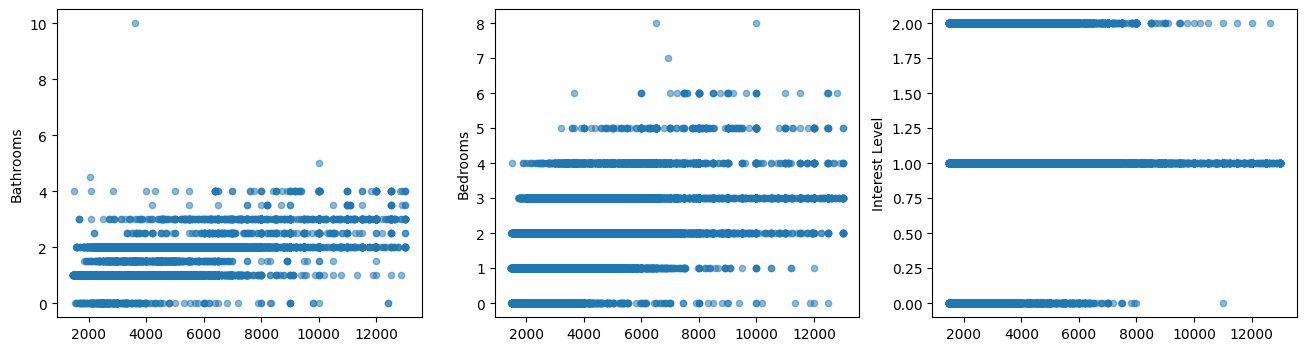

In [486]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df_q['price'], df_q['bathrooms'], alpha=0.5, s=20)
axes[0].set_ylabel('Bathrooms')

axes[1].scatter(df_q['price'], df_q['bedrooms'], alpha=0.5, s=20)
axes[1].set_ylabel('Bedrooms')

axes[2].scatter(df_q['price'], df_q['interest_level'], alpha=0.5, s=20)
axes[2].set_ylabel('Interest Level')

plt.show()

## 4. Создание функций

In [487]:
df = df_q

In [488]:
df.head()

,bathrooms,bedrooms,price,interest_level
4,1.0,1,2400,2
6,1.0,2,3800,1
9,1.0,2,3495,2
10,1.5,3,3000,2
15,1.0,0,2795,1


- Создадим квадратичные признаки, для это создадим три новых столбца

In [489]:
df['bathrooms_squared'] = df['bathrooms'] ** 2
df['bedrooms_squared'] = df['bedrooms'] ** 2
df['interest_level_squared'] = df['interest_level'] ** 2
df.head()

,bathrooms,bedrooms,price,interest_level,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,2400,2,1.00,1,4
6,1.0,2,3800,1,1.00,4,1
9,1.0,2,3495,2,1.00,4,4
10,1.5,3,3000,2,2.25,9,4
15,1.0,0,2795,1,1.00,0,1


- Построим корреляционную матрицу со старыми и новыми данными

In [490]:
corr_matrix2 = df_q[['bathrooms', 'bedrooms', 'interest_level', 'bathrooms_squared', 'bedrooms_squared', 'interest_level_squared', 'price']].corr()
corr_matrix2

,bathrooms,bedrooms,interest_level,bathrooms_squared,bedrooms_squared,interest_level_squared,price
bathrooms,1.000000,0.517574,-0.006578,0.956023,0.548760,-0.025866,0.671943
bedrooms,0.517574,1.000000,0.028754,0.478817,0.928277,0.042426,0.545948
interest_level,-0.006578,0.028754,1.000000,-0.012424,0.027602,0.950839,-0.033239
bathrooms_squared,0.956023,0.478817,-0.012424,1.000000,0.522227,-0.032822,0.648486
bedrooms_squared,0.548760,0.928277,0.027602,0.522227,1.000000,0.040017,0.543406
interest_level_squared,-0.025866,0.042426,0.950839,-0.032822,0.040017,1.000000,-0.092995
price,0.671943,0.545948,-0.033239,0.648486,0.543406,-0.092995,1.000000


- Также для наглядности покажем тепловую карту

<Axes: >

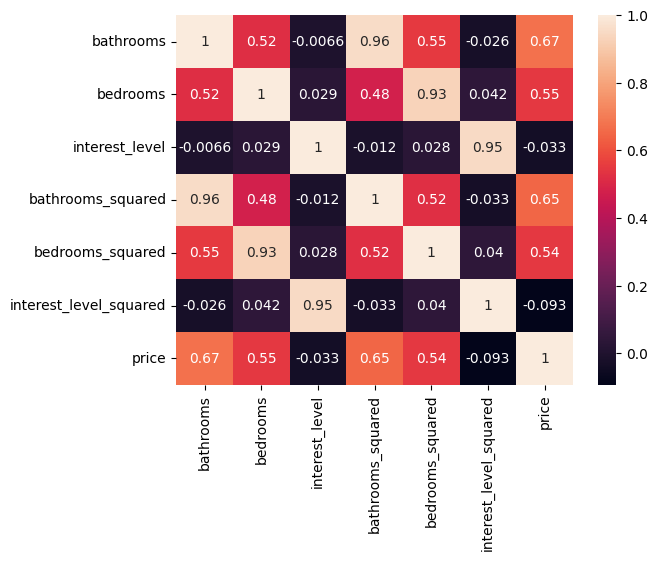

In [491]:
sns.heatmap(corr_matrix2, annot=True)

_Ответ на вопрос:_
- __Нет__, квадратичные признакине не являются более коррелированными в целевой переменной _price_

In [492]:
df_train = pd.read_json('../data/train.json')

In [493]:
df_train.head(1)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium


In [494]:
df_train = df_train[['bathrooms', 'bedrooms', 'price']]
df_train.head()

,bathrooms,bedrooms,price
4,1.0,1,2400
6,1.0,2,3800
9,1.0,2,3495
10,1.5,3,3000
15,1.0,0,2795


In [496]:
lower_q = df_train['price'].quantile(0.01)
upper_q = df_train['price'].quantile(0.99)
df_train = df_train[(df_train['price'] >= lower_q) & (df_train['price'] <= upper_q)]

In [498]:
df_test = pd.read_json('../data/test.json')

In [499]:
df_test.head(1)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street


In [500]:
df_test = df_test[['bathrooms', 'bedrooms', 'price']]
df_test.head()

,bathrooms,bedrooms,price
0,1.0,1,2950
1,1.0,2,2850
2,1.0,0,2295
3,1.0,2,2900
5,1.0,1,3254


In [502]:
lower_q = df_test['price'].quantile(0.01)
upper_q = df_test['price'].quantile(0.99)
df_test = df_test[(df_test['price'] >= lower_q) & (df_test['price'] <= upper_q)]

In [504]:
X_train = df_train[['bathrooms', 'bedrooms']]
y_train = df_train['price']

X_test = df_test[['bathrooms', 'bedrooms']]
y_test = df_test['price']

In [505]:
poly = PolynomialFeatures(degree=2)

In [506]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

##  5. Линейная регрессия, дерево решений и наивная модель.

### 5.1 Создание таблиц для результатов

In [507]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

### 5.2 Линейная регрессия

Мы уже разделили данные(они уже были поделены). X_train, y_train, X_test, y_test. 

Поэтому создадим объект линейной регрессии:

In [508]:
LinRegr = LinearRegression()

Теперь обучим наши данные 

In [509]:
LinRegr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Делаем предсказания для каждого нашего случая на тренировычных данных и на тестовых

In [510]:
y_train_predict = LinRegr.predict(X_train)
y_test_predict = LinRegr.predict(X_test)

Вычислим __MAE__ - средняя абсолтная разница мезжду предсказанием и фактическим значением.

In [511]:
mae_train = mean_absolute_error(y_train, y_train_predict)
mae_test = mean_absolute_error(y_test, y_test_predict)
mae_train, mae_test

(784.5638365414973, 790.4789216852223)

Вычислим __RMSE__ - корень из средней квадратичной разницы

In [512]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_predict))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_predict))
rmse_train, rmse_test

(1123.8777481749999, 1368.5707716497184)

Добавляем результаты в итоговую таблицу

In [513]:
result_MAE.loc[len(result_MAE)] = ['linear_regression', mae_train, mae_test]
result_MAE

,model,train,test
0,linear_regression,784.563837,790.478922


In [514]:
result_RMSE.loc[len(result_RMSE)] = ['linear_regression', rmse_train, rmse_test]
result_RMSE

,model,train,test
0,linear_regression,1123.877748,1368.570772


### 5.3 Дерево решений.

Создаём объект дерева решений

In [515]:
dtr = DecisionTreeRegressor(random_state=21)

Обучаем дерево на тренировочных данных

In [516]:
dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Делаем прогнозы

In [524]:
y_train_predict_tree = dtr.predict(X_train)
y_test_predict_tree = dtr.predict(X_test)

__MAE__

In [521]:
mae_train_tree = mean_absolute_error(y_train, y_train_predict_tree)
mae_test_tree = mean_absolute_error(y_test, y_test_predict_tree)
mae_train_tree, mae_test_tree

(756.0447348104971, 759.2941651589889)

__RMSE__

In [522]:
rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_train_predict_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_test_predict_tree))
rmse_train_tree, rmse_test_tree

(1077.4835964662536, 1081.0501940715453)

Записываем результаты

In [523]:
result_MAE.loc[len(result_MAE)] = ['decision_tree', mae_train_tree, mae_test_tree]
result_RMSE.loc[len(result_RMSE)] = ['decision_tree', rmse_train_tree, rmse_test_tree]

In [526]:
result_MAE

,model,train,test
0,linear_regression,784.563837,790.478922
1,decision_tree,756.044735,759.294165


In [527]:
result_RMSE

,model,train,test
0,linear_regression,1123.877748,1368.570772
1,decision_tree,1077.483596,1081.050194


### 5.4 Наивная модель.

Посчитаем средее и медиану на данных train и test

In [545]:
y_train_mean = y_train.mean()
y_train_median = y_train.median()

In [559]:
y_test_mean = y_test.mean()
y_test_median = y_test.median()

Создадим столбцы, полностью состоящие из медианы и среднего значения соответственно

In [ ]:
y_train_median_columns1 = np.array([y_train_median]*df_train.shape[0])
y_train_mean_columns1 = np.array([y_train_mean]*df_train.shape[0])

In [560]:
y_train_mean_columns2 = np.array([y_test_mean]*df_test.shape[0])
y_train_median_columns2 = np.array([y_test_median]*df_test.shape[0])

__MAE__

In [565]:
mae_train_mean = mean_absolute_error(y_train, y_train_mean_columns1)
mae_test_mean = mean_absolute_error(y_test, y_train_mean_columns2)
mae_train_mean, mae_test_mean

(1139.1925151949104, 1135.6278081548157)

In [564]:
mae_train_median = mean_absolute_error(y_train, y_train_median_columns1)
mae_test_median = mean_absolute_error(y_test, y_train_median_columns2)
mae_train_median, mae_test_median

(1086.2105045577628, 1084.274571131993)

__RMSE__

In [563]:
rmse_train_median = np.sqrt(mean_squared_error(y_train, y_train_median_columns1))
rmse_test_median = np.sqrt(mean_squared_error(y_test, y_train_median_columns2))
rmse_train_median, rmse_test_median

(1644.2364385837698, 1635.3759660238925)

In [566]:
rmse_train_mean = np.sqrt(mean_squared_error(y_train, y_train_mean_columns1))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, y_train_mean_columns2))
rmse_train_mean, rmse_test_mean

(1597.64665534199, 1590.089908882292)

Запишем результаты в итоговые таблицы

In [567]:
result_MAE.loc[len(result_MAE)] = ['naive_mean', mae_train_mean, mae_test_mean]
result_RMSE.loc[len(result_RMSE)] = ['naive_mean', rmse_train_mean, rmse_test_mean]
result_MAE.loc[len(result_MAE)] = ['naive_median', mae_train_median, mae_test_median]
result_RMSE.loc[len(result_RMSE)] = ['naive_median', rmse_train_median, rmse_test_median]

### 5.5 Спавнение результатов.

In [569]:
result_MAE

,model,train,test
0,linear_regression,784.563837,790.478922
1,decision_tree,756.044735,759.294165
2,naive_mean,1139.192515,1135.627808
3,naive_median,1086.210505,1084.274571


In [570]:
result_RMSE

,model,train,test
0,linear_regression,1123.877748,1368.570772
1,decision_tree,1077.483596,1081.050194
2,naive_mean,1597.646655,1590.089909
3,naive_median,1644.236439,1635.375966


- По результатам можно с уверенностью сказать, что __дерево решений__ показало себя лучше всех моделей. 

- Потом идет __линейная регрессия__, которая не сильно уступает по результатам.

- А вот __наивные модели__ далеки от правильных ответов, что очень даже логично.